In [1]:
# Cell 1: Import Libraries and Setup
"""
SYNTHETIC DATA GENERATOR FOR FRAUD DETECTION SYSTEM
Generates clean, realistic datasets with no null/invalid values
"""

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
from faker import Faker
import os

# Initialize Faker for realistic names
fake = Faker()
Faker.seed(42)  # For reproducibility
np.random.seed(42)
random.seed(42)

# Create directories if they don't exist
os.makedirs('../data/raw', exist_ok=True)

print("✅ Libraries imported and seeded successfully!")

✅ Libraries imported and seeded successfully!


In [2]:
# Cell 2: Configuration Parameters
# ============================================
# CONFIGURATION
# ============================================
NUM_CUSTOMERS = 2000
NUM_MERCHANTS = 500
NUM_TRANSACTIONS = 10000
FRAUD_RATE = 0.02  # 2% of transactions are fraudulent

# Define categories
GENDERS = ['Male', 'Female', 'Non-Binary']
INCOME_BRACKETS = ['Low', 'Medium', 'High']
EMPLOYMENT_STATUS = ['Employed', 'Self-Employed', 'Retired', 'Student']
HOME_OWNERSHIP = ['Own', 'Rent', 'Mortgage', 'Other']
MERCHANT_CATEGORIES = [
    'Retail', 'Grocery', 'Restaurant', 'Electronics', 'Travel',
    'Entertainment', 'Healthcare', 'Online', 'Gas', 'Other'
]
TRANSACTION_TYPES = ['Credit', 'Debit', 'Prepaid', 'Transfer']
DEVICE_TYPES = ['Desktop', 'Mobile', 'Tablet', 'Other']
COUNTRIES = ['US', 'UK', 'CA', 'FR', 'DE', 'JP', 'CN', 'AU', 'IN', 'BR']
RISK_CATEGORIES = ['Low', 'Medium', 'High']

print("✅ Configuration loaded!")
print(f"   - Customers: {NUM_CUSTOMERS:,}")
print(f"   - Merchants: {NUM_MERCHANTS:,}")
print(f"   - Transactions: {NUM_TRANSACTIONS:,}")
print(f"   - Fraud Rate: {FRAUD_RATE*100:.1f}%")

✅ Configuration loaded!
   - Customers: 2,000
   - Merchants: 500
   - Transactions: 10,000
   - Fraud Rate: 2.0%


In [3]:
# Cell 3: Generate Customer Data Function
# ============================================
# FUNCTION: Generate Clean Customer Data
# ============================================
def generate_customers(n=NUM_CUSTOMERS):
    """Generate synthetic customer data with no nulls"""
    
    customers = []
    for i in range(n):
        customer_id = 1001 + i
        age = random.randint(18, 85)
        gender = random.choice(GENDERS)
        income_bracket = random.choice(INCOME_BRACKETS)
        account_age_months = random.randint(1, 240)
        
        # Credit score correlates with income
        base_score = {
            'Low': random.randint(580, 700),
            'Medium': random.randint(650, 780),
            'High': random.randint(720, 850)
        }[income_bracket]
        credit_score = min(850, max(300, base_score + random.randint(-30, 30)))
        
        # Account balance correlates with income and age
        balance_base = {
            'Low': random.uniform(100, 5000),
            'Medium': random.uniform(5000, 30000),
            'High': random.uniform(15000, 80000)
        }[income_bracket]
        account_balance = round(balance_base + random.uniform(-5000, 5000), 2)
        account_balance = max(0, account_balance)
        
        num_credit_cards = random.randint(1, 5)
        employment_status = random.choice(EMPLOYMENT_STATUS)
        home_ownership = random.choice(HOME_OWNERSHIP)
        
        # 5% customers have fraud history
        is_fraud_history = random.random() < 0.05
        
        # Risk category based on multiple factors
        risk_score = 0
        if is_fraud_history: risk_score += 2
        if account_age_months < 12: risk_score += 1
        if credit_score < 650: risk_score += 1
        if account_balance < 100: risk_score += 1
        if income_bracket == 'Low': risk_score += 1
        
        if risk_score >= 4:
            risk_category = 'High'
        elif risk_score >= 2:
            risk_category = 'Medium'
        else:
            risk_category = 'Low'
        
        customers.append({
            'customer_id': customer_id,
            'age': age,
            'gender': gender,
            'income_bracket': income_bracket,
            'account_age_months': account_age_months,
            'credit_score': credit_score,
            'account_balance': account_balance,
            'num_credit_cards': num_credit_cards,
            'employment_status': employment_status,
            'home_ownership': home_ownership,
            'is_fraud_history': is_fraud_history,
            'risk_category': risk_category
        })
    
    return pd.DataFrame(customers)

print("✅ Customer generation function defined!")

✅ Customer generation function defined!


In [4]:
# Cell 4: Generate Merchant Data Function
# ============================================
# FUNCTION: Generate Clean Merchant Data
# ============================================
def generate_merchants(n=NUM_MERCHANTS):
    """Generate synthetic merchant data with no nulls"""
    
    # Real merchant names (for realism)
    real_merchants = [
        'Amazon', 'Walmart', 'Starbucks', 'Best Buy', 'Expedia',
        'Netflix', 'CVS Pharmacy', 'Shell', 'Apple Store', 'McDonalds',
        'Target', 'Alibaba', 'Airbnb', 'Spotify', 'Mayo Clinic',
        'Harrods', 'Tesla Motors', 'Disney World', 'GameStop', 'Etsy',
        'Costco', 'Whole Foods', 'Home Depot', 'Kroger', 'Walgreens',
        'Nike', 'Adidas', 'Samsung', 'Microsoft', 'Google Store',
        'Uber', 'Lyft', 'DoorDash', 'Grubhub', 'Instacart',
        'Zara', 'H&M', 'Sephora', 'Ulta', 'Lowes',
        'Macy\'s', 'Nordstrom', 'Saks', 'Tiffany', 'Rolex',
        'Porsche', 'BMW', 'Mercedes', 'Audi', 'Lexus',
        'Marriott', 'Hilton', 'Hyatt', 'Four Seasons', 'Ritz-Carlton',
        'LinkedIn', 'Facebook', 'Twitter', 'Snapchat', 'TikTok',
        'PayPal', 'Venmo', 'Square', 'Stripe', 'Shopify'
    ]
    
    # High-risk merchant names
    high_risk_merchants = [
        'Dark Web Mart', 'Fake Store Inc', 'Suspicious Shop',
        'Dodgy Deals', 'Black Market Goods', 'Counterfeit Central'
    ]
    
    merchants = []
    for i in range(n):
        merchant_id = 5001 + i
        
        # Use real names first, then generate fake ones
        if i < len(real_merchants):
            merchant_name = real_merchants[i]
        else:
            merchant_name = f"{fake.company()} {random.choice(['Store', 'Mart', 'Shop', 'Center'])}"
        
        merchant_category = random.choice(MERCHANT_CATEGORIES)
        
        # Some merchants are high risk
        if merchant_name in high_risk_merchants or random.random() < 0.03:
            is_high_risk = True
            merchant_category = random.choice(['Online', 'Other'])
        else:
            is_high_risk = False
        
        # Average amount varies by category
        category_avg = {
            'Retail': random.uniform(20, 200),
            'Grocery': random.uniform(15, 150),
            'Restaurant': random.uniform(10, 100),
            'Electronics': random.uniform(50, 1000),
            'Travel': random.uniform(100, 5000),
            'Entertainment': random.uniform(10, 300),
            'Healthcare': random.uniform(50, 2000),
            'Online': random.uniform(10, 500),
            'Gas': random.uniform(20, 80),
            'Other': random.uniform(10, 300)
        }[merchant_category]
        
        avg_transaction_amount = round(category_avg + random.uniform(-30, 30), 2)
        avg_transaction_amount = max(5, avg_transaction_amount)
        
        country = random.choice(COUNTRIES)
        
        # High risk merchants have more fraud reports
        if is_high_risk:
            fraud_reports = random.randint(10, 50)
        else:
            fraud_reports = random.randint(0, 5)
        
        established_year = random.randint(1980, 2026)
        
        merchants.append({
            'merchant_id': merchant_id,
            'merchant_name': merchant_name,
            'merchant_category': merchant_category,
            'is_high_risk': is_high_risk,
            'avg_transaction_amount': avg_transaction_amount,
            'country': country,
            'fraud_reports': fraud_reports,
            'established_year': established_year
        })
    
    return pd.DataFrame(merchants)

print("✅ Merchant generation function defined!")

✅ Merchant generation function defined!


In [5]:
# Cell 5: Generate Transaction Data Function
# ============================================
# FUNCTION: Generate Clean Transaction Data
# ============================================
def generate_transactions(customers_df, merchants_df, n=NUM_TRANSACTIONS, fraud_rate=FRAUD_RATE):
    """Generate synthetic transaction data with no nulls"""
    
    transactions = []
    
    # Pre-compute customer averages for realistic amounts
    customer_avg = {}
    for _, customer in customers_df.iterrows():
        income_factor = {
            'Low': 1.0,
            'Medium': 2.0,
            'High': 4.0
        }[customer['income_bracket']]
        
        # Base average spending per customer
        base_avg = 20 + (customer['account_age_months'] / 12) * 10
        customer_avg[customer['customer_id']] = base_avg * income_factor
    
    # Track last transaction time per customer
    last_transaction_time = {}
    
    for i in range(n):
        transaction_id = i + 1
        
        # Pick random customer and merchant
        customer_id = random.choice(customers_df['customer_id'].tolist())
        merchant_id = random.choice(merchants_df['merchant_id'].tolist())
        
        # Get merchant info
        merchant = merchants_df[merchants_df['merchant_id'] == merchant_id].iloc[0]
        merchant_category = merchant['merchant_category']
        is_high_risk_merchant = merchant['is_high_risk']
        
        # Generate amount based on customer profile
        avg_amount = customer_avg[customer_id]
        amount_variance = random.uniform(0.5, 3.0)
        transaction_amount = round(avg_amount * amount_variance, 2)
        transaction_amount = max(1, transaction_amount)
        
        # Sometimes larger transactions
        if random.random() < 0.1:
            transaction_amount = round(transaction_amount * random.uniform(3, 10), 2)
            transaction_amount = min(50000, transaction_amount)
        
        # Generate realistic timestamp (2026-08-09)
        day = random.randint(1, 30)
        hour = random.randint(0, 23)
        minute = random.randint(0, 59)
        second = random.randint(0, 59)
        timestamp = f"2026-08-{day:02d} {hour:02d}:{minute:02d}:{second:02d}"
        
        # Determine if online/international
        is_online = random.random() < 0.6
        is_international = random.random() < 0.15
        
        # Device type based on online status
        if is_online:
            device_type = random.choice(['Desktop', 'Mobile', 'Tablet'])
        else:
            device_type = random.choice(['Tablet', 'Other'])
        
        # IP location
        ip_location = random.choice(COUNTRIES)
        if not is_international:
            ip_location = 'US'
        
        # Previous transactions in 24h (realistic)
        previous_transactions_24h = random.choices(
            [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
            weights=[0.4, 0.25, 0.15, 0.08, 0.04, 0.03, 0.02, 0.01, 0.01, 0.005, 0.005]
        )[0]
        
        # Days since last transaction
        if customer_id in last_transaction_time:
            last_txn = last_transaction_time[customer_id]
            days_since = random.randint(0, 30)
        else:
            days_since = random.randint(0, 365)
        last_transaction_time[customer_id] = timestamp
        
        # Calculate amount_to_avg_ratio
        amount_to_avg_ratio = round(transaction_amount / avg_amount, 2)
        amount_to_avg_ratio = min(50, amount_to_avg_ratio)
        
        # Determine if transaction is fraudulent (2% chance)
        # But make fraud more realistic based on patterns
        is_fraud = False
        
        # Calculate fraud probability based on risk factors
        fraud_probability = 0.02  # Base rate
        
        # Risk factors
        if is_international: fraud_probability += 0.05
        if is_high_risk_merchant: fraud_probability += 0.10
        if amount_to_avg_ratio > 3: fraud_probability += 0.08
        if transaction_amount > 5000: fraud_probability += 0.05
        if hour < 6 or hour > 23: fraud_probability += 0.03
        if previous_transactions_24h > 5: fraud_probability += 0.04
        
        # Customer risk factors
        customer = customers_df[customers_df['customer_id'] == customer_id].iloc[0]
        if customer['is_fraud_history']: fraud_probability += 0.10
        if customer['account_age_months'] < 3: fraud_probability += 0.05
        if customer['risk_category'] == 'High': fraud_probability += 0.05
        
        # Cap probability
        fraud_probability = min(0.95, fraud_probability)
        
        # Determine if fraud occurs
        if random.random() < fraud_probability:
            is_fraud = True
            # For fraud transactions, make them more extreme
            transaction_amount = round(transaction_amount * random.uniform(5, 15), 2)
            transaction_amount = min(50000, transaction_amount)
            amount_to_avg_ratio = round(transaction_amount / avg_amount, 2)
            is_international = True
            is_online = True
            ip_location = random.choice(['CN', 'BR', 'RU', 'IN'])
            device_type = random.choice(['Desktop', 'Mobile'])
        
        # Ensure at least 2% fraud rate
        if random.random() < 0.005 and not is_fraud:  # Extra random fraud
            is_fraud = True
            transaction_amount = round(transaction_amount * random.uniform(8, 20), 2)
            transaction_amount = min(50000, transaction_amount)
            amount_to_avg_ratio = round(transaction_amount / avg_amount, 2)
        
        transactions.append({
            'transaction_id': transaction_id,
            'customer_id': customer_id,
            'merchant_id': merchant_id,
            'transaction_amount': transaction_amount,
            'timestamp': timestamp,
            'is_online': is_online,
            'is_international': is_international,
            'is_fraud': is_fraud,
            'transaction_type': random.choice(TRANSACTION_TYPES),
            'device_type': device_type,
            'ip_location': ip_location,
            'previous_transactions_24h': previous_transactions_24h,
            'amount_to_avg_ratio': amount_to_avg_ratio,
            'days_since_last_txn': days_since
        })
    
    return pd.DataFrame(transactions)

print("✅ Transaction generation function defined!")

✅ Transaction generation function defined!


In [6]:
# Cell 6: Generate All Data
print("=" * 60)
print("SYNTHETIC DATA GENERATOR FOR FRAUD DETECTION")
print("=" * 60)

# 1. Generate Customers
print("\n📊 Generating Customers...")
customers_df = generate_customers(NUM_CUSTOMERS)
customers_df.to_csv('../data/raw/customers.csv', index=False)
print(f"✅ Generated {len(customers_df)} customers")
print(f"   - Unique IDs: {customers_df['customer_id'].min():,} to {customers_df['customer_id'].max():,}")
print(f"   - No null values: {not customers_df.isnull().any().any()}")

# 2. Generate Merchants
print("\n🏪 Generating Merchants...")
merchants_df = generate_merchants(NUM_MERCHANTS)
merchants_df.to_csv('../data/raw/merchants.csv', index=False)
print(f"✅ Generated {len(merchants_df)} merchants")
print(f"   - Unique IDs: {merchants_df['merchant_id'].min():,} to {merchants_df['merchant_id'].max():,}")
print(f"   - No null values: {not merchants_df.isnull().any().any()}")

# 3. Generate Transactions
print("\n💳 Generating Transactions...")
transactions_df = generate_transactions(customers_df, merchants_df, NUM_TRANSACTIONS, FRAUD_RATE)
transactions_df.to_csv('../data/raw/transactions.csv', index=False)
print(f"✅ Generated {len(transactions_df)} transactions")
print(f"   - Fraud rate: {transactions_df['is_fraud'].mean()*100:.2f}%")
print(f"   - No null values: {not transactions_df.isnull().any().any()}")

SYNTHETIC DATA GENERATOR FOR FRAUD DETECTION

📊 Generating Customers...
✅ Generated 2000 customers
   - Unique IDs: 1,001 to 3,000
   - No null values: True

🏪 Generating Merchants...
✅ Generated 500 merchants
   - Unique IDs: 5,001 to 5,500
   - No null values: True

💳 Generating Transactions...
✅ Generated 10000 transactions
   - Fraud rate: 6.23%
   - No null values: True


In [7]:
# Cell 7: Data Validation Summary
print("\n" + "=" * 60)
print("📈 DATA VALIDATION SUMMARY")
print("=" * 60)

print("\n1. Customers Data Quality:")
print(f"   - Total records: {len(customers_df):,}")
print(f"   - Unique customers: {customers_df['customer_id'].nunique():,}")
print(f"   - Age range: {customers_df['age'].min():,} to {customers_df['age'].max():,}")
print(f"   - Credit score range: {customers_df['credit_score'].min():,} to {customers_df['credit_score'].max():,}")
print(f"   - Risk distribution:")
for risk in RISK_CATEGORIES:
    count = len(customers_df[customers_df['risk_category'] == risk])
    pct = count / len(customers_df) * 100
    print(f"     • {risk}: {count:,} ({pct:.1f}%)")

print("\n2. Merchants Data Quality:")
print(f"   - Total records: {len(merchants_df):,}")
print(f"   - High risk merchants: {merchants_df['is_high_risk'].sum():,}")
print(f"   - Fraud reports range: {merchants_df['fraud_reports'].min():,} to {merchants_df['fraud_reports'].max():,}")
print(f"   - Categories: {', '.join(merchants_df['merchant_category'].unique())}")

print("\n3. Transactions Data Quality:")
print(f"   - Total records: {len(transactions_df):,}")
print(f"   - Fraud transactions: {transactions_df['is_fraud'].sum():,} ({transactions_df['is_fraud'].mean()*100:.2f}%)")
print(f"   - Amount range: ${transactions_df['transaction_amount'].min():,.2f} to ${transactions_df['transaction_amount'].max():,.2f}")
print(f"   - Average amount: ${transactions_df['transaction_amount'].mean():,.2f}")
print(f"   - Online transactions: {transactions_df['is_online'].sum():,} ({transactions_df['is_online'].mean()*100:.1f}%)")
print(f"   - International transactions: {transactions_df['is_international'].sum():,} ({transactions_df['is_international'].mean()*100:.1f}%)")

print("\n4. Relationship Integrity:")
# Check customer-foreign key
invalid_customers = ~transactions_df['customer_id'].isin(customers_df['customer_id'])
print(f"   - Valid customer links: {not invalid_customers.any()}")

# Check merchant-foreign key
invalid_merchants = ~transactions_df['merchant_id'].isin(merchants_df['merchant_id'])
print(f"   - Valid merchant links: {not invalid_merchants.any()}")

print("\n" + "=" * 60)
print("✅ All CSV files generated successfully!")
print("📁 Files created:")
print("   - customers.csv")
print("   - merchants.csv")
print("   - transactions.csv")
print("=" * 60)


📈 DATA VALIDATION SUMMARY

1. Customers Data Quality:
   - Total records: 2,000
   - Unique customers: 2,000
   - Age range: 18 to 85
   - Credit score range: 553 to 850
   - Risk distribution:
     • Low: 1,455 (72.8%)
     • Medium: 522 (26.1%)
     • High: 23 (1.1%)

2. Merchants Data Quality:
   - Total records: 500
   - High risk merchants: 15
   - Fraud reports range: 0 to 47
   - Categories: Other, Retail, Gas, Grocery, Travel, Electronics, Online, Entertainment, Healthcare, Restaurant

3. Transactions Data Quality:
   - Total records: 10,000
   - Fraud transactions: 623 (6.23%)
   - Amount range: $10.76 to $50,000.00
   - Average amount: $1,338.65
   - Online transactions: 6,153 (61.5%)
   - International transactions: 1,947 (19.5%)

4. Relationship Integrity:
   - Valid customer links: True
   - Valid merchant links: True

✅ All CSV files generated successfully!
📁 Files created:
   - customers.csv
   - merchants.csv
   - transactions.csv


In [8]:
# Cell 8: Sample Data Preview
print("\n📋 Sample Data Preview:")
print("\n--- Customers (first 5) ---")
display(customers_df.head())

print("\n--- Merchants (first 5) ---")
display(merchants_df.head())

print("\n--- Transactions (first 5) ---")
display(transactions_df.head())

# Display DataFrame info
print("\n" + "=" * 60)
print("📊 DATAFRAME INFORMATION")
print("=" * 60)
print("\nCustomers DataFrame:")
print(customers_df.info())

print("\nMerchants DataFrame:")
print(merchants_df.info())

print("\nTransactions DataFrame:")
print(transactions_df.info())


📋 Sample Data Preview:

--- Customers (first 5) ---


,customer_id,age,gender,income_bracket,account_age_months,credit_score,account_balance,num_credit_cards,employment_status,home_ownership,is_fraud_history,risk_category
0,1001,32,Male,High,71,772,51353.75,1,Employed,Own,False,Low
1,1002,82,Non-Binary,Low,144,603,6045.59,4,Retired,Mortgage,False,Medium
2,1003,61,Male,Low,98,600,0.00,4,Employed,Mortgage,False,Medium
3,1004,64,Non-Binary,Low,181,607,0.00,3,Student,Mortgage,False,Medium
4,1005,63,Male,High,69,767,44559.84,5,Self-Employed,Mortgage,False,Low



--- Merchants (first 5) ---


,merchant_id,merchant_name,merchant_category,is_high_risk,avg_transaction_amount,country,fraud_reports,established_year
0,5001,Amazon,Other,False,54.75,CN,2,1984
1,5002,Walmart,Retail,False,7.53,US,0,1981
2,5003,Starbucks,Gas,False,38.12,AU,4,1999
3,5004,Best Buy,Gas,False,73.61,AU,3,1980
4,5005,Expedia,Grocery,False,119.97,UK,0,2008



--- Transactions (first 5) ---


,transaction_id,customer_id,merchant_id,transaction_amount,timestamp,is_online,is_international,is_fraud,transaction_type,device_type,ip_location,previous_transactions_24h,amount_to_avg_ratio,days_since_last_txn
0,1,2910,5339,432.58,2026-08-26 22:11:22,False,True,False,Prepaid,Tablet,FR,2,1.85,307
1,2,1341,5339,636.24,2026-08-19 14:39:39,False,False,False,Transfer,Tablet,US,0,8.30,277
2,3,1798,5437,2619.12,2026-08-13 05:53:46,True,True,True,Prepaid,Desktop,IN,2,11.22,158
3,4,1595,5343,462.98,2026-08-17 03:32:12,True,False,False,Debit,Tablet,US,1,2.25,350
4,5,1789,5386,48.49,2026-08-29 00:30:07,True,False,False,Credit,Desktop,US,0,1.45,113



📊 DATAFRAME INFORMATION

Customers DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         2000 non-null   int64  
 1   age                 2000 non-null   int64  
 2   gender              2000 non-null   str    
 3   income_bracket      2000 non-null   str    
 4   account_age_months  2000 non-null   int64  
 5   credit_score        2000 non-null   int64  
 6   account_balance     2000 non-null   float64
 7   num_credit_cards    2000 non-null   int64  
 8   employment_status   2000 non-null   str    
 9   home_ownership      2000 non-null   str    
 10  is_fraud_history    2000 non-null   bool   
 11  risk_category       2000 non-null   str    
dtypes: bool(1), float64(1), int64(5), str(5)
memory usage: 174.0 KB
None

Merchants DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (

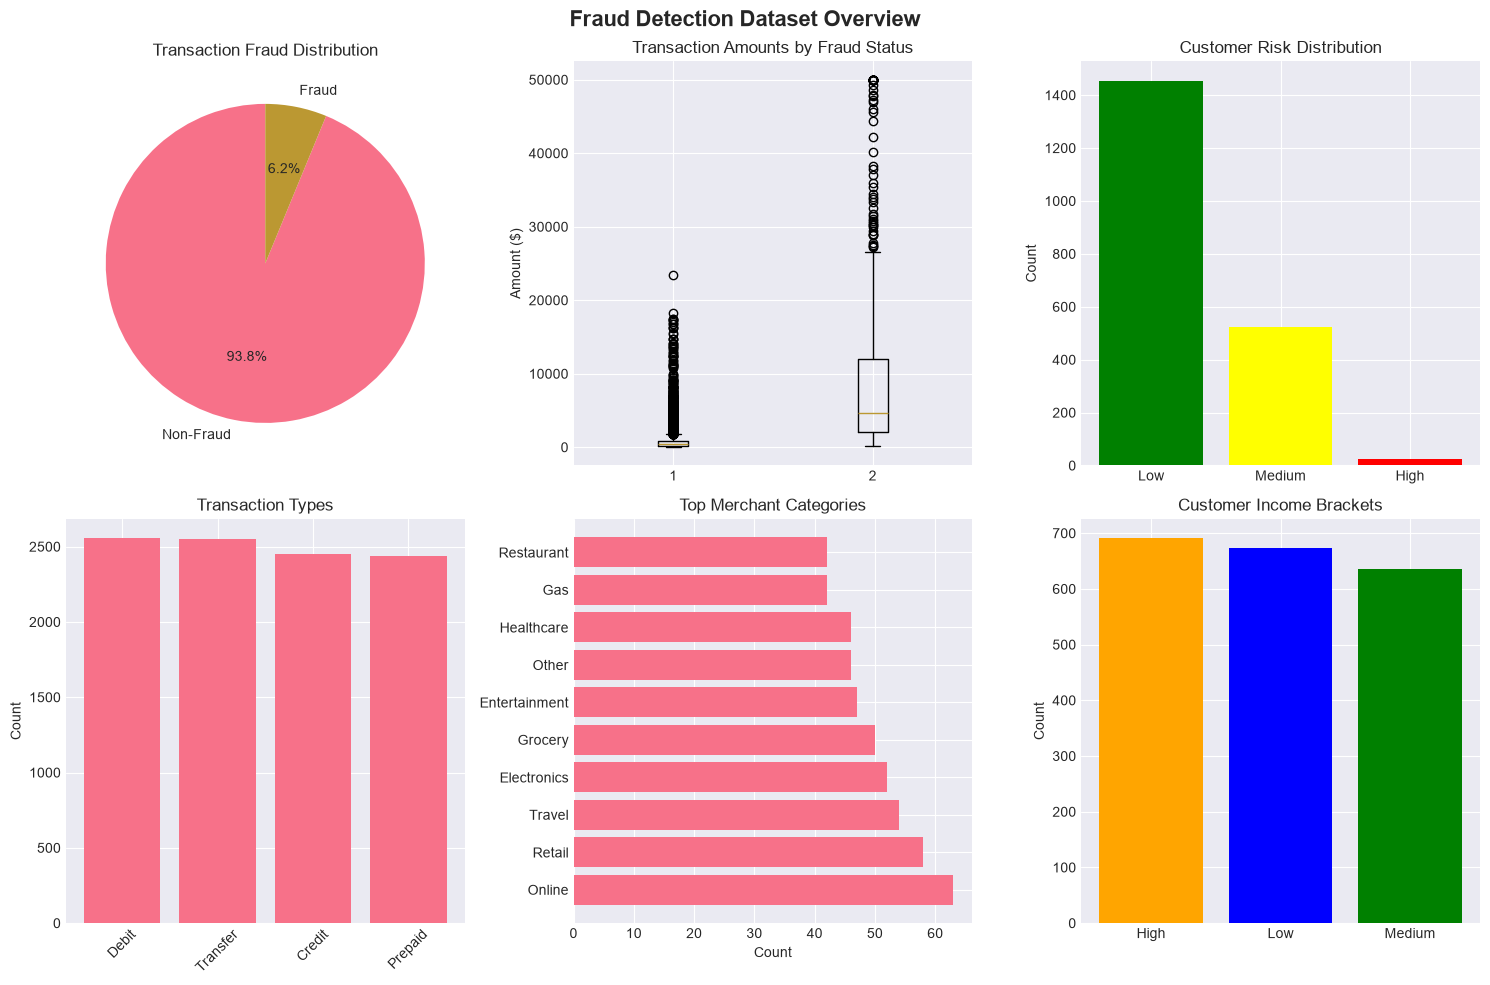

In [10]:
# Cell 9: Quick Statistics and Visualizations (Optional)
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create a figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Fraud Detection Dataset Overview', fontsize=16, fontweight='bold')

# 1. Fraud Distribution
fraud_counts = transactions_df['is_fraud'].value_counts()
axes[0, 0].pie(fraud_counts.values, labels=['Non-Fraud', 'Fraud'], 
               autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Transaction Fraud Distribution')

# 2. Transaction Amounts by Fraud Status
fraud_status = transactions_df['is_fraud'].map({0: 'Non-Fraud', 1: 'Fraud'})
axes[0, 1].boxplot([transactions_df[transactions_df['is_fraud']==0]['transaction_amount'],
                    transactions_df[transactions_df['is_fraud']==1]['transaction_amount']],
                   label=['Non-Fraud', 'Fraud'])
axes[0, 1].set_title('Transaction Amounts by Fraud Status')
axes[0, 1].set_ylabel('Amount ($)')

# 3. Customer Risk Categories
risk_counts = customers_df['risk_category'].value_counts()
axes[0, 2].bar(risk_counts.index, risk_counts.values, color=['green', 'yellow', 'red'])
axes[0, 2].set_title('Customer Risk Distribution')
axes[0, 2].set_ylabel('Count')

# 4. Transaction Types
type_counts = transactions_df['transaction_type'].value_counts()
axes[1, 0].bar(type_counts.index, type_counts.values)
axes[1, 0].set_title('Transaction Types')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Merchant Categories
cat_counts = merchants_df['merchant_category'].value_counts().head(10)
axes[1, 1].barh(cat_counts.index, cat_counts.values)
axes[1, 1].set_title('Top Merchant Categories')
axes[1, 1].set_xlabel('Count')

# 6. Income Bracket Distribution
income_counts = customers_df['income_bracket'].value_counts()
axes[1, 2].bar(income_counts.index, income_counts.values, color=['orange', 'blue', 'green'])
axes[1, 2].set_title('Customer Income Brackets')
axes[1, 2].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [11]:
# Cell 10: Save Combined Summary (Optional)
# Create a summary dictionary
summary = {
    'customers_count': len(customers_df),
    'merchants_count': len(merchants_df),
    'transactions_count': len(transactions_df),
    'fraud_count': transactions_df['is_fraud'].sum(),
    'fraud_rate': transactions_df['is_fraud'].mean(),
    'avg_transaction_amount': transactions_df['transaction_amount'].mean(),
    'max_transaction_amount': transactions_df['transaction_amount'].max(),
    'online_pct': transactions_df['is_online'].mean(),
    'international_pct': transactions_df['is_international'].mean()
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv('../data/raw/dataset_summary.csv', index=False)
print("✅ Summary saved to dataset_summary.csv")

✅ Summary saved to dataset_summary.csv


In [1]:
print('tushar')

tushar
